In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import numpy as np
from lmfit import Model
import scienceplots

# ---------------------------------------------------------------------------
#  Matplotlib Styles
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42,

   })
# ---------------------------------------------------------------------------
# 1. Load Data
# ---------------------------------------------------------------------------
file_path = "Lab_dispersivity.xlsx"
df = pd.read_excel(file_path, sheet_name='Database', header=0)


lmfit Statistics:
  c                  = 0.3475
  a                  = 0.4004
  b                  = 0.6771
  R²                 = 0.8217
  Chi-square         = 6.4983
  Reduced Chi-square = 0.0866
  AIC                = -187.8434
  BIC                = -180.7733
  Valid Pe range     = 0.2 – 6307


C:\Users\mouly\AppData\Local\Temp\ipykernel_15168\265949059.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


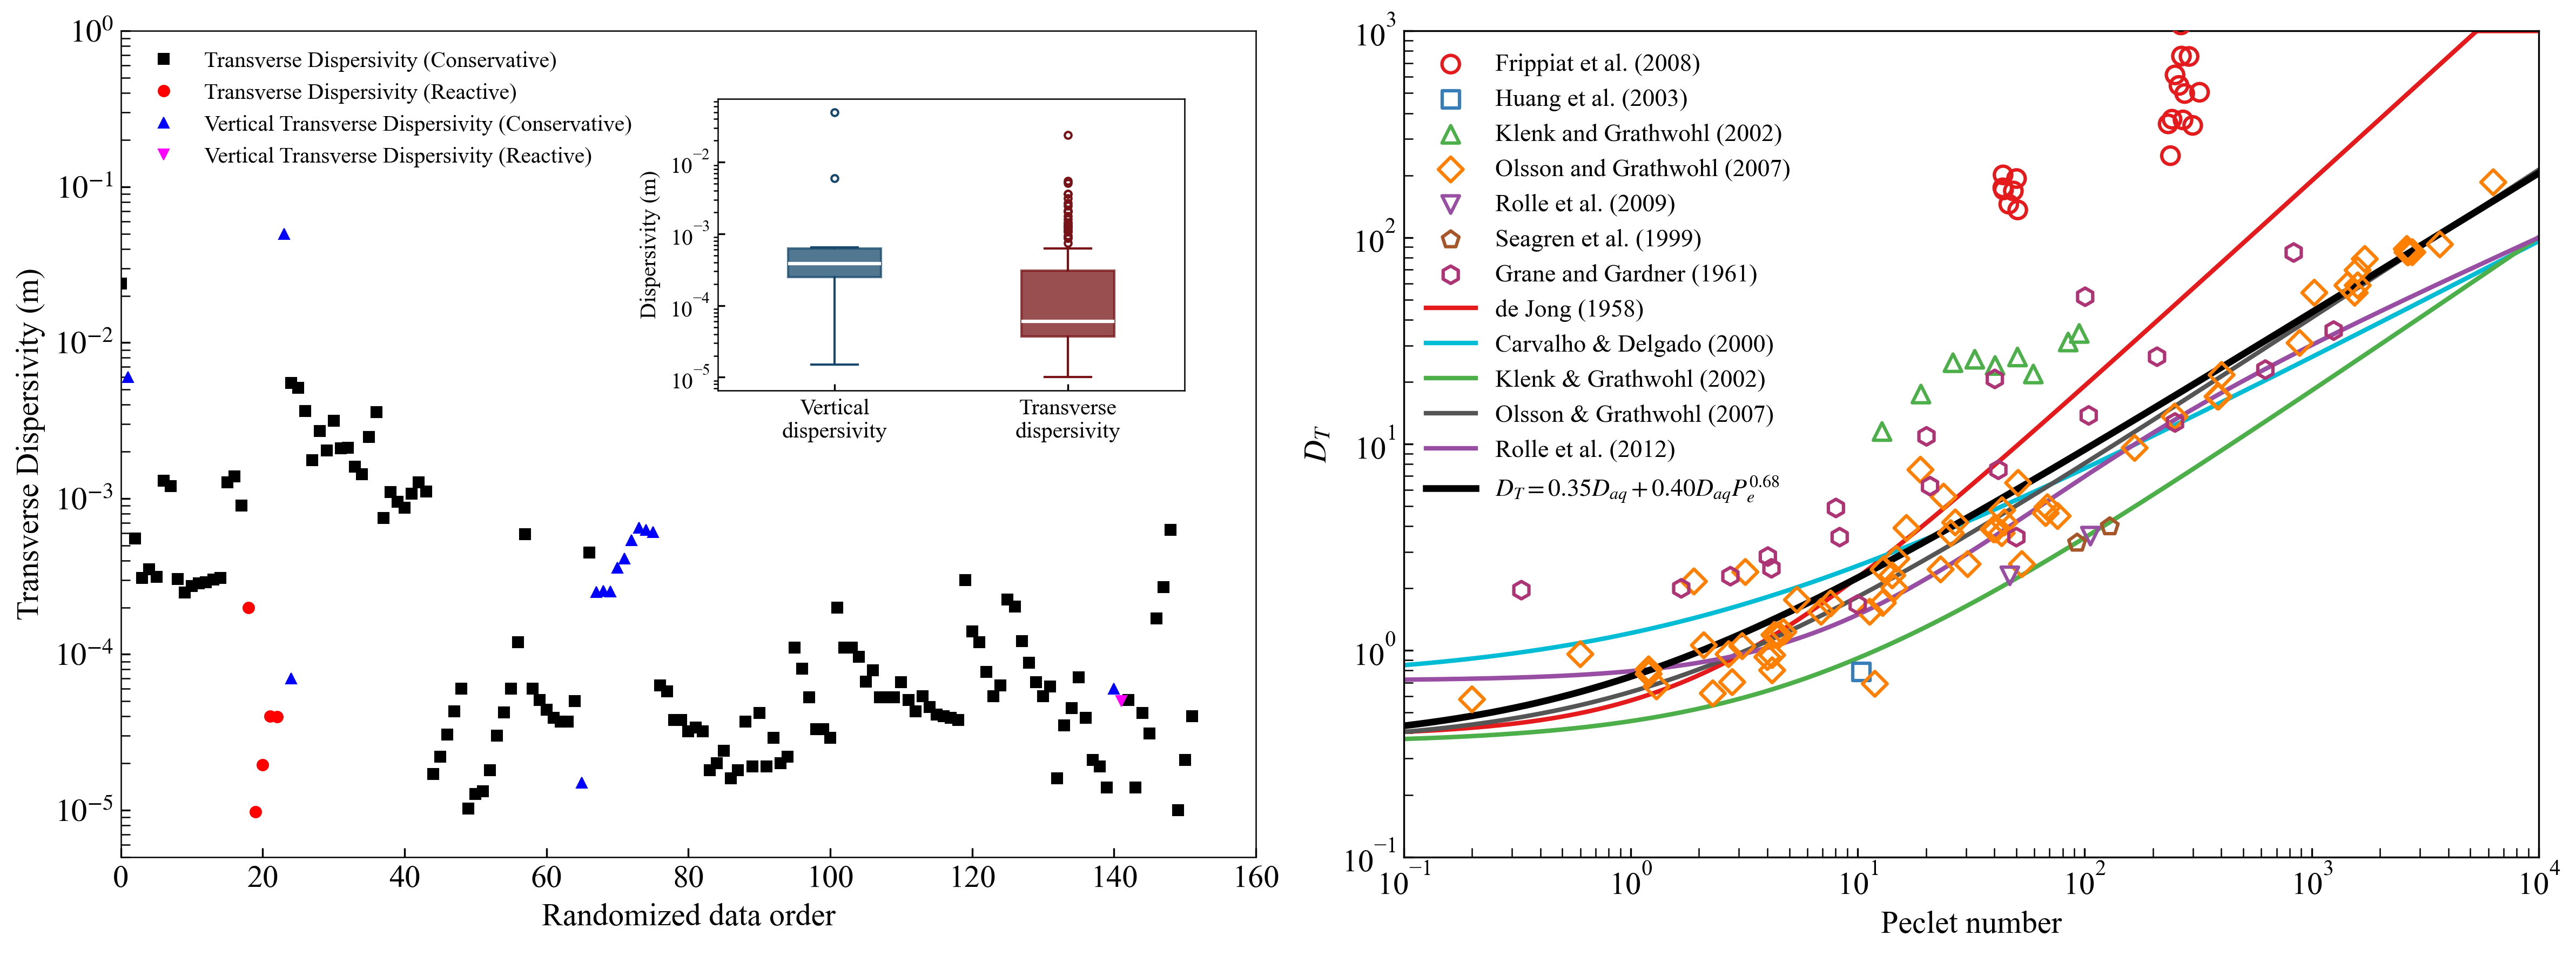

In [12]:
# =====================================================================
# --- Setup ---
# =====================================================================
reference_col  = 'Reference'
peclet_col     = 'Peclet number'
disp_ratio_col = 'Dt / Daq'

ref_styles = {
    'Frippiat et al. (2008)':      {'color': '#e41a1c', 'marker': 'o'},
    'Huang et al. (2003)':         {'color': '#377eb8', 'marker': 's'},
    'Klenk and Grathwohl (2002)':  {'color': '#4daf4a', 'marker': '^'},
    'Olsson and Grathwohl (2007)': {'color': '#ff7f00', 'marker': 'D'},
    'Rolle et al. (2009)':         {'color': '#984ea3', 'marker': 'v'},
    'Seagren et al. (1999)':       {'color': '#a65628', 'marker': 'p'},
    'Grane and Gardner (1961)':    {'color': '#ad3475', 'marker': 'h'},
}

# =====================================================================
# --- Filter data ---
# =====================================================================
df_filtered = df[df[reference_col].isin(ref_styles)].copy()
df_filtered = df_filtered.dropna(subset=[peclet_col, disp_ratio_col])
df_filtered = df_filtered[(df_filtered[peclet_col] > 0) & (df_filtered[disp_ratio_col] > 0)]

# =====================================================================
# --- Fit (lmfit) ---
# =====================================================================

df_fit = df_filtered[
    (df_filtered[reference_col] != 'Frippiat et al. (2008)') &
    (df_filtered[reference_col] != 'Grane and Gardner (1961)')
]
Pe_data = df_fit[peclet_col].values
Dt_data = df_fit[disp_ratio_col].values

def log_model(Pe, c, a, b):
    return np.log10(c + a * Pe**b)

params = Model(log_model).make_params(c=0.36, a=0.19, b=0.78)
params['c'].min = 0.01
params['a'].min = 0.01
params['b'].min = 0.5
params['b'].max = 1.5

result = Model(log_model).fit(np.log10(Dt_data), params, Pe=Pe_data)
c      = result.params['c'].value
a_fit  = result.params['a'].value
b_fit  = result.params['b'].value

# --- lmfit statistics ---
y_true = np.log10(Dt_data)
y_pred = result.best_fit
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2     = 1 - ss_res / ss_tot

print("\nlmfit Statistics:")
print(f"  c                  = {c:.4f}")
print(f"  a                  = {a_fit:.4f}")
print(f"  b                  = {b_fit:.4f}")
print(f"  R\u00b2                 = {r2:.4f}")        #squared symbol
print(f"  Chi-square         = {result.chisqr:.4f}")
print(f"  Reduced Chi-square = {result.redchi:.4f}")
print(f"  AIC                = {result.aic:.4f}")
print(f"  BIC                = {result.bic:.4f}")
print(f"  Valid Pe range     = {Pe_data.min():.1f} \u2013 {Pe_data.max():.0f}")     #dash symbol

# =====================================================================
# --- Curves (computed fresh here, right before plotting) ---
# =====================================================================
x    = np.logspace(-1, 4, 600)
YMIN, YMAX = 0.1, 1e3
clip = lambda y: np.clip(y, YMIN, YMAX)

n_dejong  = 0.385
n_klenk   = 0.355
n_olsson  = 0.35

y_dejong   = clip(n_dejong + (3 / 16) * x)
y_carvalho = clip(1 / 1.4 + 0.5 * x**0.57)
y_klenk    = clip(n_klenk + 0.1 * x**0.75)
y_olsson   = clip(n_olsson + 0.28 * x**0.72)
y_rolle    = clip(1 / 1.4 + x / np.sqrt(x + 156))
y_global   = clip(c + a_fit * x**b_fit)

# =====================================================================
# --- Figure ---
# =====================================================================
PLOT_STYLES = {
    'Alpha_T':        {'marker': 's', 'color': 'black',   'label': 'Transverse Dispersivity (Conservative)'},
    'Alpha_T_react':  {'marker': 'o', 'color': 'red',     'label': 'Transverse Dispersivity (Reactive)'},
    'Alpha_TV':       {'marker': '^', 'color': 'blue',    'label': 'Vertical Transverse Dispersivity (Conservative)'},
    'Alpha_TV_react': {'marker': 'v', 'color': 'magenta', 'label': 'Vertical Transverse Dispersivity (Reactive)'},
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

# ── Subplot 1: Scatter + Inset ─────────────────────────────
for col, style in PLOT_STYLES.items():
    if col in df.columns:
        data = df[col].dropna()
        if not data.empty:
            ax1.plot(data.index, data.values, linestyle='None',
                     marker=style['marker'], color=style['color'],
                     markersize=5, markerfacecolor=style['color'],
                     markeredgewidth=0.5, label=style['label'])
ax1.set_yscale('log')
ax1.set_xlim(0, 160)
ax1.set_ylim(5e-6, 1)
ax1.set_yticks([1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1])
ax1.set_yticklabels([r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$',
                      r'$10^{-2}$', r'$10^{-1}$', r'$10^{0}$'])
ax1.set_xlabel('Randomized data order',fontsize=14)
ax1.set_ylabel('Transverse Dispersivity (m)',fontsize=14)
ax1.tick_params(axis='both', direction='in', length=4)
ax1.legend(loc='upper left', fontsize=10, frameon=False)
for spine in ax1.spines.values():
    spine.set_linewidth(0.6)
ax1.tick_params(axis='both', which='both', direction='in', length=4, labelsize=14)
# inset
ax_inset = fig.add_axes([0.28, 0.59, 0.18, 0.30])
box_colors = ["#18496C", "#771216"]
bp = ax_inset.boxplot([df['Alpha_TV'].dropna(), df['Alpha_T'].dropna()],
                       patch_artist=True, widths=0.4)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set(facecolor=color, edgecolor=color, alpha=0.75)
for element in ['whiskers', 'caps']:
    for i, line in enumerate(bp[element]):
        line.set_color(box_colors[i // 2])
for line in bp['medians']:
    line.set(color='white', linewidth=1.5)
for i, flier in enumerate(bp['fliers']):
    flier.set(marker='o', markerfacecolor='none',
              markeredgecolor=box_colors[i], markersize=3)
ax_inset.set_yscale('log')
ax_inset.set_xticks([1, 2])
ax_inset.set_xticklabels(['Vertical\ndispersivity', 'Transverse\ndispersivity'], fontsize=10)
ax_inset.tick_params(axis='both', direction='in', labelsize=10, length=3)
ax_inset.set_ylabel('Dispersivity (m)', fontsize=10)
for spine in ax_inset.spines.values():
    spine.set_linewidth(0.6)

# ── Subplot 2: Pe fit ──────────────────────────────────────
for ref, style in ref_styles.items():
    grp = df_filtered[df_filtered[reference_col] == ref]
    if not grp.empty:
        ax2.scatter(grp[peclet_col], grp[disp_ratio_col],
                    label=ref, marker=style['marker'], s=60,
                    facecolors='none', edgecolors=style['color'],
                    linewidth=1.5, zorder=12)

ax2.plot(x, y_dejong,   '-', lw=2, color='#e41a1c', label='de Jong (1958)')
ax2.plot(x, y_carvalho, '-', lw=2, color='#00bcd4', label='Carvalho & Delgado (2000)')
ax2.plot(x, y_klenk,    '-', lw=2, color='#4daf4a', label='Klenk & Grathwohl (2002)')
ax2.plot(x, y_olsson,   '-', lw=2, color='#555555', label='Olsson & Grathwohl (2007)')
ax2.plot(x, y_rolle,    '-', lw=2, color='#984ea3', label='Rolle et al. (2012)')
ax2.plot(x, y_global,   '-', lw=3, color='black',
         label=rf'$D_T = {c:.2f}D_{{aq}} + {a_fit:.2f}D_{{aq}}P_e^{{{b_fit:.2f}}}$')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlim(0.1, 1e4)
ax2.set_ylim(YMIN, YMAX)
ax2.set_xlabel('Peclet number',fontsize= 14)
ax2.set_ylabel(r'$D_T$',fontsize= 14)
ax2.xaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax2.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax2.legend(loc='upper left', fontsize=11, frameon=False)
ax2.tick_params(axis='both', which='both', direction='in', length=4, labelsize=14)

plt.tight_layout()
plt.savefig("fig2.pdf", dpi=1500, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none',)
plt.show()